In [55]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
#1. import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb



In [56]:
#2.Load the dataset
df = pd.read_csv('Desktop/SS/tips dataset.csv')

In [57]:
# Print the first five rows
print(df.head())

   total_bill     tip  gender smoker   day    time  size
0     2125.50  360.79    Male     No  Thur   Lunch     1
1     2727.18  259.42  Female     No   Sun  Dinner     5
2     1066.02  274.68  Female    Yes  Thur  Dinner     4
3     3493.45  337.90  Female     No   Sun  Dinner     1
4     3470.56  567.89    Male    Yes   Sun   Lunch     6


In [58]:
#3. Preprocess categorical features using one _Hot Encoding
df_encoded=pd.get_dummies(df,columns=['gender','smoker','day','time'],drop_first=False)

In [59]:
#4. Seperate features (X) and target (y)
X = df_encoded.drop(columns=['tip'])
y =df_encoded['tip']

In [60]:
5.# Split  into training and testing sets(80% train, 20% test)
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
#Training set size
print(f"\nTraining set size:{X_train.shape[0]} samples")
print(f"Testing set size:{X_test.shape[0]}samples")


Training set size:595 samples
Testing set size:149samples


In [62]:
#6. Initialize and training the XGboost regressor model
model =xgb.XGBRegressor(n_estimators=100, max_depth=4,learning_rate=0.08,random_state=42)
model.fit(X_train,y_train)
print("\nModel training completed succesfully!")


Model training completed succesfully!


In [63]:
#7. Make predictiosns on the test
y_pred=model.predict(X_test)

In [64]:
# Evaluate the model
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error(MSE):{mse:.2f}")
print(f"Root mean Squared Error(RMSE):{rmse:.2f}")
print(f"R-squared(R2)Score:{r2:.4f}")



--- Model Evaluation Metrics ---
Mean Squared Error(MSE):25876.47
Root mean Squared Error(RMSE):160.86
R-squared(R2)Score:0.0499


In [65]:

# 9. Show feature importances
importance = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print("\n--- Feature Importances ---")
print(importance)




--- Feature Importances ---
day_Thur         0.138533
day_Sat          0.106607
total_bill       0.100391
day_Sun          0.093212
day_Wed          0.092543
gender_Female    0.091451
day_Tues         0.075557
size             0.070075
day_Fri          0.059888
smoker_No        0.059883
day_Mon          0.057805
time_Dinner      0.054055
gender_Male      0.000000
smoker_Yes       0.000000
time_Lunch       0.000000
dtype: float32


In [71]:
#Plot features
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,16))


<Figure size 1000x1600 with 0 Axes>

<Figure size 1000x1600 with 0 Axes>

C:\Users\USER\AppData\Local\Temp\ipykernel_12604\1750065566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values,y=importance.index,palette="viridis",legend = False)


<Axes: ylabel='None'>

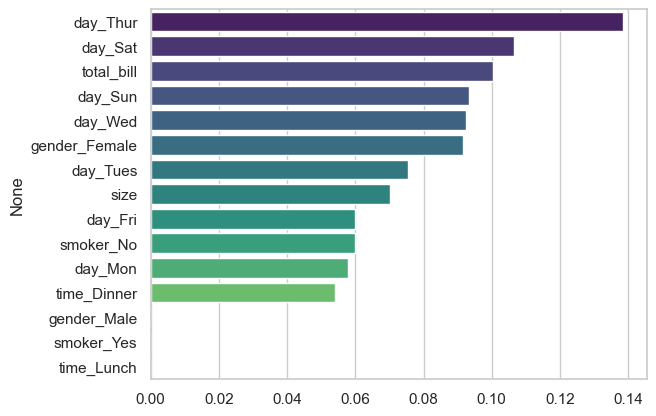

In [74]:
# Horizontal barplot
sns.barplot(x=importance.values,y=importance.index,palette="viridis",legend = False)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

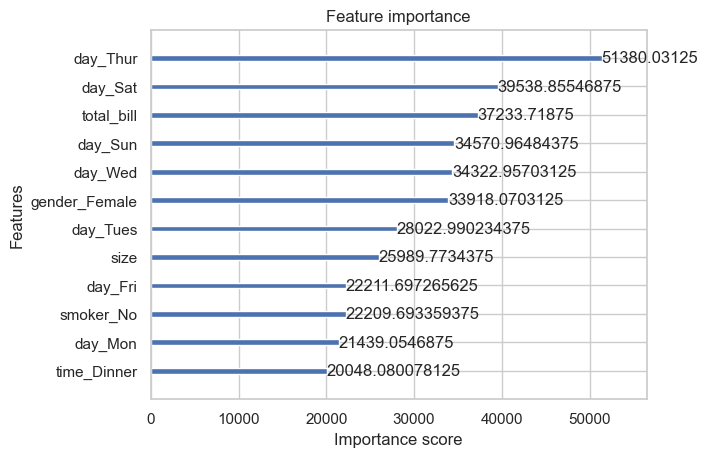

In [76]:
#Use the built -in XGBoost plotter
xgb.plot_importance(model,importance_type='gain',ax=plt.gca())

In [77]:
# Change to "whitegrid"
sns.set_theme(style="whitegrid")

In [78]:
# Replace the dataframe with actual variables
plt.figure(figsize=(10,16))

<Figure size 1000x1600 with 0 Axes>

<Figure size 1000x1600 with 0 Axes>

In [79]:
#3.
import matplotlib.pyplot as plt
import xgboost as xgb


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

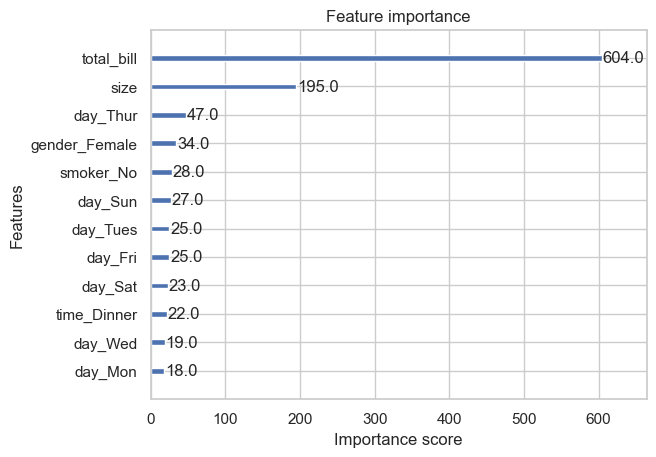

In [80]:
xgb.plot_importance(model)